## Monty Hall Problem

You are playing a TV game show and are shown 2 doors. One has a car behind it, the other a goat. What are your chances of picking the door with the car?

OK, now there are 3 doors: one with a car, two with goats. The game show host asks you to pick a door, but not to open it yet. Then the host opens one of the other two doors (that you did not pick) and that has a goat. The host offers you the opportunity to switch doors.

- One player decides to switch
- Another player prefers to stay with the previous choice
- Now a third player comes in who has not seen what happened earlier. They pick a door.
Which of the three players is most likely to win?


Simulate three doors, one car, and two goats.
Simulate three players: the switcher, the conservative, and the newcomer.
Record who wins.
Repeat it many times.
Which player do you want to be?

Food for thought: And what if you had $N$ doors to choose from and the presenter opens $p \leq N$ of them? Study how the probability of winning changes as a function of $p$ and $N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

## 2 doors

In [ ]:
doors = np.zeros(2, dtype = int)
tries = 1000
wins = 0
for n in range(tries):
    car_idx = random.randint(0,1)
    pick = random.randint(0,1)
    if pick == car_idx:
        wins +=1

print('chance of winning: ', wins/tries*100, '%')

chance of winning:  50.0 %


## 3 doors

In [64]:
ndoors = 3
tries = 10000

keeper_wins = 0
switcher_wins = 0
newcomer_wins = 0

for n in range(tries):
    car_idx = random.randint(0,ndoors-1)
    keeper_idx = random.randint(0,ndoors-1)

    host_doors = list(np.arange(ndoors))
    host_doors.remove(car_idx)

    if keeper_idx == car_idx:
        keeper_wins +=1

    else:
        host_doors.remove(keeper_idx)
    
    host_idx = random.choice(host_doors)

    switcher_doors = list(np.arange(ndoors))
    switcher_doors.remove(host_idx)
    switcher_doors.remove(keeper_idx)
    switcher_idx = random.choice(switcher_doors)

    if switcher_idx == car_idx:
        switcher_wins +=1

    newcomer_doors = list(np.arange(ndoors))
    newcomer_doors.remove(host_idx)
    newcomer_idx = random.choice(newcomer_doors)

    if newcomer_idx == car_idx:
        newcomer_wins +=1

print('keeper win rate: ', keeper_wins/tries*100, '%')
print('switcher win rate: ', switcher_wins/tries*100, '%')
print('newcomer win rate: ', newcomer_wins/tries*100, '%')

keeper win rate:  33.72 %
switcher win rate:  66.28 %
newcomer win rate:  49.58 %


## N doors, opening p \leq N

In [48]:
ndoors = 50
tries = 100

keeper_wins = 0
switcher_wins = np.zeros(ndoors, dtype = int)
newcomer_wins = np.zeros(ndoors, dtype = int)

for n in range(tries):
    car_idx = random.randint(0,ndoors-1)
    keeper_idx = random.randint(0,ndoors-1)

    host_doors = list(np.arange(ndoors))
    host_doors.remove(car_idx)

    if keeper_idx == car_idx:
        keeper_wins +=1

    else:
        host_doors.remove(keeper_idx)
    
    for p in range(1,ndoors-1):

        host_idx = np.random.choice(host_doors, size = p, replace = False)

        switcher_doors = list(np.arange(ndoors))
        newcomer_doors = list(np.arange(ndoors))

        switcher_doors.remove(keeper_idx)
        for d in range(len(host_idx)):
                switcher_doors.remove(host_idx[d])
        switcher_idx = random.choice(switcher_doors)

        if switcher_idx == car_idx:
            switcher_wins[p] +=1

        for d in range(len(host_idx)):
                newcomer_doors.remove(host_idx[d])
        newcomer_idx = random.choice(newcomer_doors)

        if newcomer_idx == car_idx:
            newcomer_wins[p] +=1


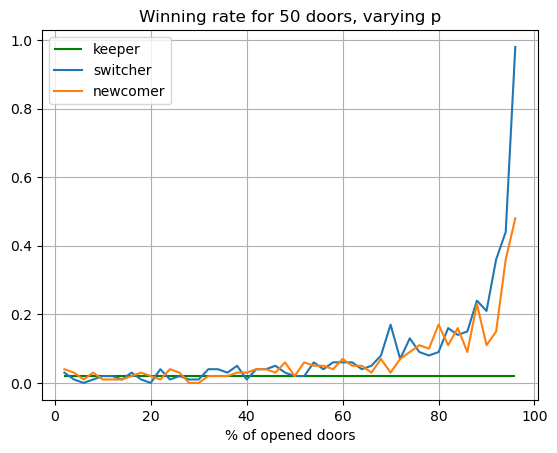

In [49]:
plt.title(f'Winning rate for {ndoors} doors, varying p')
plt.hlines(keeper_wins/tries, xmin = 1/ndoors*100, xmax = (ndoors-2)/ndoors*100, label = 'keeper', color = 'green')
plt.plot(np.arange(1,ndoors-1)/ndoors*100,(switcher_wins/tries)[1:-1], label = 'switcher')
plt.plot(np.arange(1,ndoors-1)/ndoors*100,(newcomer_wins/tries)[1:-1], label = 'newcomer')
plt.xlabel('% of opened doors')
plt.grid(True)
plt.legend()

## N doors, opening p (fixed)

In [54]:
ndoors_max = 100
tries = 1000
p = 5

keeper_wins = np.zeros(ndoors_max, dtype = int)
switcher_wins = np.zeros(ndoors_max, dtype = int)
newcomer_wins = np.zeros(ndoors_max, dtype = int)

for ndoors in range(10,ndoors_max):

    for n in range(tries):

        car_idx = random.randint(0,ndoors-1)
        keeper_idx = random.randint(0,ndoors-1)

        host_doors = list(np.arange(ndoors))
        host_doors.remove(car_idx)

        if keeper_idx == car_idx:
            keeper_wins[ndoors] +=1

        else:
            host_doors.remove(keeper_idx)

        host_idx = np.random.choice(host_doors, size = p, replace = False)

        switcher_doors = list(np.arange(ndoors))
        newcomer_doors = list(np.arange(ndoors))

        switcher_doors.remove(keeper_idx)
        for d in range(len(host_idx)):
                switcher_doors.remove(host_idx[d])
        switcher_idx = random.choice(switcher_doors)

        if switcher_idx == car_idx:
            switcher_wins[ndoors] +=1

        for d in range(len(host_idx)):
                newcomer_doors.remove(host_idx[d])
        newcomer_idx = random.choice(newcomer_doors)

        if newcomer_idx == car_idx:
            newcomer_wins[ndoors] +=1


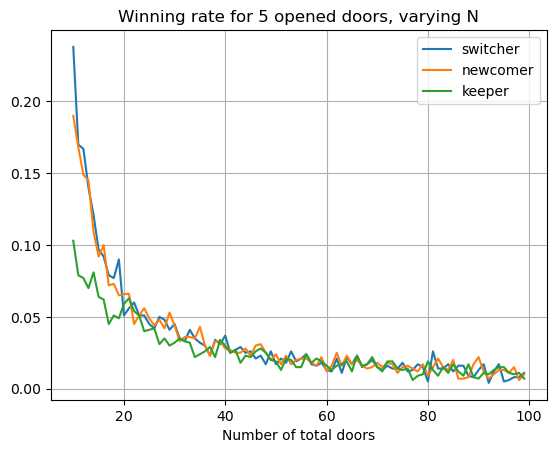

In [55]:
plt.title(f'Winning rate for {p} opened doors, varying N')
plt.plot(np.arange(10,ndoors_max),(switcher_wins/tries)[10:], label = 'switcher')
plt.plot(np.arange(10,ndoors_max),(newcomer_wins/tries)[10:], label = 'newcomer')
plt.plot(np.arange(10,ndoors_max),(keeper_wins/tries)[10:], label = 'keeper')
plt.xlabel('Number of total doors')
plt.grid(True)
plt.legend()